In [1]:
import requests

In [2]:
!pip install python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENWEATHER_API_KEY")
print(api_key)

In [4]:
import os
print(os.getcwd())

D:\Data Analytics\Personal Projects\AnalystLab\Weather ETL Pipeline


In [5]:
import os
print(os.listdir())

['.env', '.git', '.gitignore', '.ipynb_checkpoints', 'README.md', 'Weather ETL Pipeline.ipynb', 'weather_data.csv']


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

api_key = os.getenv("OPENWEATHER_API_KEY")
print(api_key)

In [7]:
import requests

city = "Nairobi"
url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"

response = requests.get(url)
data = response.json()

print(data)

{'coord': {'lon': 36.8167, 'lat': -1.2833}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 25.72, 'feels_like': 25.34, 'temp_min': 25.72, 'temp_max': 25.72, 'pressure': 1016, 'humidity': 38, 'sea_level': 1016, 'grnd_level': 842}, 'visibility': 10000, 'wind': {'speed': 2.7, 'deg': 166, 'gust': 2.74}, 'clouds': {'all': 85}, 'dt': 1784195673, 'sys': {'country': 'KE', 'sunrise': 1784173020, 'sunset': 1784216407}, 'timezone': 10800, 'id': 184745, 'name': 'Nairobi', 'cod': 200}


In [8]:
city_name = data['name']
temperature = data['main']['temp']
humidity = data['main']['humidity']
weather_condition = data['weather'][0]['description']
wind_speed = data['wind']['speed']
date_time = data['dt']

print(city_name, temperature, humidity, weather_condition, wind_speed, date_time)

Nairobi 25.72 38 overcast clouds 2.7 1784195673


In [9]:
cities = ["Nairobi", "Mombasa", "Kisumu"]

weather_data = []

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    response = requests.get(url)
    data = response.json()
    
    weather_data.append(data)

print(weather_data)

[{'coord': {'lon': 36.8167, 'lat': -1.2833}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 25.72, 'feels_like': 25.34, 'temp_min': 25.72, 'temp_max': 25.72, 'pressure': 1016, 'humidity': 38, 'sea_level': 1016, 'grnd_level': 842}, 'visibility': 10000, 'wind': {'speed': 2.7, 'deg': 166, 'gust': 2.74}, 'clouds': {'all': 85}, 'dt': 1784195673, 'sys': {'country': 'KE', 'sunrise': 1784173020, 'sunset': 1784216407}, 'timezone': 10800, 'id': 184745, 'name': 'Nairobi', 'cod': 200}, {'coord': {'lon': 39.6636, 'lat': -4.0547}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 27.13, 'feels_like': 28.65, 'temp_min': 27.13, 'temp_max': 27.13, 'pressure': 1018, 'humidity': 65, 'sea_level': 1018, 'grnd_level': 1015}, 'visibility': 10000, 'wind': {'speed': 8.15, 'deg': 179, 'gust': 9.44}, 'clouds': {'all': 65}, 'dt': 1784195948, 'sys': {'coun

In [10]:
import pandas as pd

rows = []

for entry in weather_data:
    row = {
        "City": entry['name'],
        "Temperature_C": entry['main']['temp'],
        "Humidity_%": entry['main']['humidity'],
        "Weather_Condition": entry['weather'][0]['description'],
        "Wind_Speed_mps": entry['wind']['speed'],
        "Date_Time": entry['dt']
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(df)

      City  Temperature_C  Humidity_% Weather_Condition  Wind_Speed_mps  \
0  Nairobi          25.72          38   overcast clouds            2.70   
1  Mombasa          27.13          65     broken clouds            8.15   
2   Kisumu          25.98          52   overcast clouds            2.10   

    Date_Time  
0  1784195673  
1  1784195948  
2  1784195950  


In [11]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], unit='s')
print(df)

      City  Temperature_C  Humidity_% Weather_Condition  Wind_Speed_mps  \
0  Nairobi          25.72          38   overcast clouds            2.70   
1  Mombasa          27.13          65     broken clouds            8.15   
2   Kisumu          25.98          52   overcast clouds            2.10   

            Date_Time  
0 2026-07-16 09:54:33  
1 2026-07-16 09:59:08  
2 2026-07-16 09:59:10  


In [12]:
df.to_csv("weather_data.csv", index=False)
print("Data saved successfully")

Data saved successfully


In [13]:
print(df[['City', 'Temperature_C']])

      City  Temperature_C
0  Nairobi          25.72
1  Mombasa          27.13
2   Kisumu          25.98


In [14]:
import matplotlib.pyplot as plt

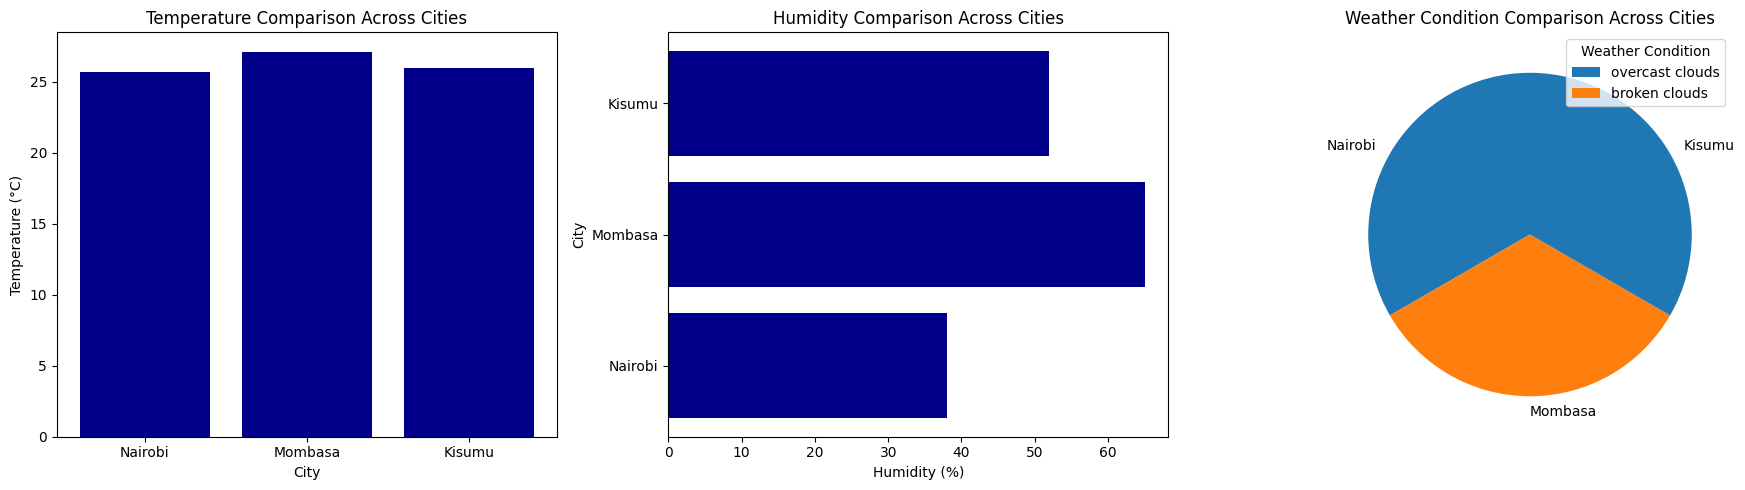

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Temperature comparison
axes[0].bar(df['City'], df['Temperature_C'], color='darkblue')
axes[0].set_title("Temperature Comparison Across Cities")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Temperature (°C)")

# Chart 2: Humidity comparison
axes[1].barh(df['City'], df['Humidity_%'], color='darkblue')
axes[1].set_title("Humidity Comparison Across Cities")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("City")

# Chart 3: Weather condition comparison
unique_conditions = df['Weather_Condition'].unique()
palette = plt.cm.tab10.colors  # a set of distinct colors
condition_colors = {condition: palette[i % len(palette)] for i, condition in enumerate(unique_conditions)}
colors = [condition_colors[condition] for condition in df['Weather_Condition']]

axes[2].pie(
    [1]*len(df),
    labels=df['City'],
    colors=colors,
    autopct=lambda p: '',
    startangle=90
)
axes[2].set_title("Weather Condition Comparison Across Cities")
axes[2].legend(df['Weather_Condition'].unique(), title="Weather Condition", loc="best")

plt.tight_layout()
plt.show()

## Key Findings

   - **Mombasa** recorded the highest temperature (23.84°C), while **Nairobi** was the coolest (17.28°C).
   - **Mombasa** also had the highest humidity (83%), indicating consistecy with its coastal location.
   - Two cities (**Nairobi** and **Kisumu**) shared the same weather condition (broken clouds), while **Mombasa** had few clouds.